# Autoencoder with ACCESS-OM2

Autoencoder with ACCESS-OM2 Ocean Heat Content Data

This notebook trains an autoencoder on ocean heat content and surface heat flux data from the ACCESS-OM2 model using partial convolutions to handle land-masked regions.

In [1]:
# -----------------------------------------------------------------------------
# Cell purpose: import dependencies and define paths/device for full workflow.
# Outcome: pipeline/data/model/plot modules are loaded and local utils are importable.
# -----------------------------------------------------------------------------
# System and path handling
import sys
from pathlib import Path

# Data handling
import numpy as np
import pandas as pd
import xarray as xr

# PyEarthTools pipeline
import pyearthtools.data as petdata
from pyearthtools.data.transforms import TransformCollection
import pyearthtools.pipeline as petpipe
import pyearthtools.data.archive as arch

# Deep learning
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# Visualization
import matplotlib.pyplot as plt

# Configure device and random seed
torch.manual_seed(42)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Source data and code directories
userbase = "/g/data/v46/txs156/"
repobase = "/home/156/txs156/uom/OM2-emulator/"

# Add the src directory to the Python path (relative to notebook location)
src_path = Path(repobase) / "src"
sys.path.insert(0, str(src_path))

# Import the ACCESS_OHC data accessor from om2_data_utils module
from om2_data_utils import ACCESS_OHC

# Import the PartialConv2d layer from om2_model_utils module


In [2]:
# -----------------------------------------------------------------------------
# Cell purpose: define the normalisation strategies to compare mode-by-mode.
# Convention: this list order is reused consistently in loops, plots, and diagnostics.
# -----------------------------------------------------------------------------
# normalisation_strategies = ["Global_in_time_and_space",
#                             "Spatial_over_all_times",
#                             "Spatial_per_month",
#                             "Hybrid_OHC_spatial_SHF_monthly"]
# normalisation_strategies = ["Global_in_time_and_space",
#                             "Spatial_over_all_times",
#                             "Spatial_per_month",
normalisation_strategies = ["Hybrid_OHC_spatial_SHF_monthly"]


## Setup PyEarthTools data accessor and pipeline

In [3]:
# -----------------------------------------------------------------------------
# Cell purpose: configure accessor and compute normalisation statistics datasets.
# Key transform context: OHC anomaly and cumulative HF are prepared before stats.
# -----------------------------------------------------------------------------
# Setup the data accessor and pipeline
ACCESS_OHC_accessor = ACCESS_OHC(
    ["area_t", "ocean_heat_content_2d", "total_surface_heat_flx"],
    root=userbase + "OM2-emulator/data/",
)

# Keep one explicit time window so all normalisation paths are directly comparable.
normalisation_start = '2000-01'
normalisation_end = '2018-12'
normalisation_interval = '1 month'
normalisation_window = dict(start=normalisation_start, end=normalisation_end, interval=normalisation_interval)
normalised_variables = ["ocean_heat_content_2d", "total_surface_heat_flx"]

# -----------------------------------------------------------------------------
# Build normalisation stats explicitly from ocean-only values (land -> NaN),
# then use skipna reductions so land never contributes to mean/std.
# -----------------------------------------------------------------------------
ds_stats = xr.open_dataset(userbase + "OM2-emulator/data/1deg_ocean_heat_emulator_data.nc")
ds_stats = ds_stats.sel(time=slice(normalisation_start, normalisation_end))
ds_stats = ds_stats[normalised_variables]

# Keep mask derivation consistent with training/diagnostics convention:
# 1 = ocean, 0 = land.
mask_xr = xr.where(np.isnan(ds_stats.total_surface_heat_flx.isel(time=0)), 0, 1)
masked_stats = ds_stats.where(mask_xr == 1)

# Align spatial dimension names with the pipeline (Sort uses latitude/longitude).
rename_map = {}
if "yt_ocean" in masked_stats.dims:
    rename_map["yt_ocean"] = "latitude"
if "xt_ocean" in masked_stats.dims:
    rename_map["xt_ocean"] = "longitude"
if rename_map:
    masked_stats = masked_stats.rename(rename_map)

# 1) Global stats (scalar per variable)
global_mean_stats = masked_stats.mean(dim=("time", "latitude", "longitude"), skipna=True)
global_std_stats = masked_stats.std(dim=("time", "latitude", "longitude"), skipna=True)

# 2) Spatial stats (per-gridcell over all times)
spatial_mean_stats = masked_stats.mean(dim="time", skipna=True)
spatial_std_stats = masked_stats.std(dim="time", skipna=True)

# 3) Spatial climatology (month-wise per gridcell) then tile over all years.
spatial_monthly_mean_stats = masked_stats.groupby("time.month").mean(dim="time", skipna=True)
spatial_monthly_std_stats = masked_stats.groupby("time.month").std(dim="time", skipna=True)

month_indexer = xr.DataArray(
    masked_stats.time.dt.month.values,
    coords={"time": masked_stats.time.values},
    dims="time",
)
spatial_monthly_mean_stats = spatial_monthly_mean_stats.sel(month=month_indexer).drop_vars("month", errors="ignore")
spatial_monthly_std_stats = spatial_monthly_std_stats.sel(month=month_indexer).drop_vars("month", errors="ignore")

/opt/conda/envs/pet/lib/python3.11/site-packages/numbagg/decorators.py:527: RuntimeWarning: invalid value encountered in group_nanstd
  gufunc(*args)


In [4]:
# -----------------------------------------------------------------------------
# Cell purpose: stabilise std fields and construct PET normalisation operators.
# We clip near-zero std values to avoid divide-by-zero in masked/constant regions.
# -----------------------------------------------------------------------------
# Prevent divide-by-zero in fully masked/constant regions.
eps = 1e-6
global_std_stats = global_std_stats.where(global_std_stats > eps, eps)
spatial_std_stats = spatial_std_stats.where(spatial_std_stats > eps, eps)
spatial_monthly_std_stats = spatial_monthly_std_stats.where(spatial_monthly_std_stats > eps, eps)

# Keep only model variables for consistency.
keep_vars = [v for v in normalised_variables if v in global_mean_stats.data_vars]
global_mean_stats = global_mean_stats[keep_vars]
global_std_stats = global_std_stats[keep_vars]
spatial_mean_stats = spatial_mean_stats[keep_vars]
spatial_std_stats = spatial_std_stats[keep_vars]
spatial_monthly_mean_stats = spatial_monthly_mean_stats[keep_vars]
spatial_monthly_std_stats = spatial_monthly_std_stats[keep_vars]

# Drop curvilinear geolocation coords from stats datasets so they match the
# pipeline structure after Drop(['geolat_t', 'geolon_t']) and avoid alignment
# side effects during xarray normalisation -> ToNumpy conversion.
for _ds_name in [
    "global_mean_stats",
    "global_std_stats",
    "spatial_mean_stats",
    "spatial_std_stats",
    "spatial_monthly_mean_stats",
    "spatial_monthly_std_stats",
]:
    _ds = locals()[_ds_name]
    _drop_coords = [c for c in ["geolat_t", "geolon_t"] if c in _ds.coords or c in _ds.data_vars]
    if _drop_coords:
        _ds = _ds.drop_vars(_drop_coords, errors='ignore')
    locals()[_ds_name] = _ds

# 4) Hybrid stats: OHC uses all-time spatial stats, surface flux uses monthly climatology stats.
hybrid_mean_stats = xr.Dataset({
    "ocean_heat_content_2d": spatial_mean_stats["ocean_heat_content_2d"],
    "total_surface_heat_flx": spatial_monthly_mean_stats["total_surface_heat_flx"],
})
hybrid_std_stats = xr.Dataset({
    "ocean_heat_content_2d": spatial_std_stats["ocean_heat_content_2d"],
    "total_surface_heat_flx": spatial_monthly_std_stats["total_surface_heat_flx"],
})
hybrid_std_stats = hybrid_std_stats.where(hybrid_std_stats > eps, eps)

# Define pipeline normalisation operations for each strategy.
pipelines_normed = [
    petpipe.operations.xarray.normalisation.Evaluated(
        normalisation_eval="(sample - mean) / deviation",
        unnormalisation_eval="(sample * deviation) + mean",
        mean=hybrid_mean_stats,
        deviation=hybrid_std_stats,
    ),
]


In [5]:
# -----------------------------------------------------------------------------
# Cell purpose: spot-check monthly std fields to detect pathological magnitudes/NaNs.
# -----------------------------------------------------------------------------
ohc_std = spatial_monthly_std_stats.ocean_heat_content_2d
ohc_cnt = masked_stats.ocean_heat_content_2d.groupby("time.month").count(dim="time")

print("std min:", float(ohc_std.min(skipna=True)))
print("std quantiles:", np.nanpercentile(ohc_std.values, [0, 1, 5, 50, 95, 99]))
print("std <= 1e-6:", int(np.isfinite(ohc_std.values).sum() and (ohc_std.values <= 1e-6).sum()))

print("count min/max:", int(ohc_cnt.min()), int(ohc_cnt.max()))
print("count<=1 cells:", int((ohc_cnt <= 1).sum()))


std min: 9.999999974752427e-07
std quantiles: [9.99999997e-07 9.99999997e-07 9.99999997e-07 9.99999997e-07
 2.34918989e+09 3.09945395e+09]
std <= 1e-6: 14228036
count min/max: 0 19
count<=1 cells: 458292


In [6]:
# -----------------------------------------------------------------------------
# Cell purpose: assemble one PET pipeline per normalisation mode and load full
# time series per mode (not just one iterator sample).
# -----------------------------------------------------------------------------
full_grid_over_time = []
pipelines = []

all_np_by_mode = []
train_np_by_mode = []
eval_np_by_mode = []
time_by_mode = []

for mode_idx, norm_op in enumerate(pipelines_normed):
    print(mode_idx, normalisation_strategies[mode_idx])

    pipeline_i = petpipe.Pipeline(
        ACCESS_OHC_accessor,
        petdata.transforms.coordinates.Drop(['geolat_t', 'geolon_t']),
        petdata.transforms.variables.Drop(['area_t']),
        petpipe.operations.xarray.select.SelectDataset(normalised_variables),
        petpipe.operations.xarray.Sort(order=normalised_variables, strict=True),
        petpipe.operations.xarray.reshape.Dimensions(["time", "latitude", "longitude"]),
        norm_op,
        petpipe.operations.xarray.values.FillNan(0),
        petpipe.operations.xarray.conversion.ToNumpy(),
        petpipe.operations.numpy.reshape.Rearrange('c t h w -> t c h w'),
        iterator=petpipe.iterators.DateRange(normalisation_start, normalisation_end, interval=normalisation_interval),
    )

    pipelines.append(pipeline_i)
    full_grid_over_time.append(pipeline_i)

    samples = []
    for sample in pipeline_i:  # each sample has shape (1, C, H, W)
        samples.append(sample)

    if len(samples) == 0:
        raise ValueError(f"No samples produced for mode {normalisation_strategies[mode_idx]}")

    full_series = np.concatenate(samples, axis=0)  # (T, C, H, W)
    n_time = full_series.shape[0]

    if n_time < 2:
        raise ValueError("Need at least 2 timesteps to perform an 80/20 time split.")

    split_idx = int(np.floor(0.8 * n_time))
    split_idx = min(max(split_idx, 1), n_time - 1)

    train_np = full_series[:split_idx]
    eval_np = full_series[split_idx:]  # latest 20%

    mode_times = pd.DatetimeIndex(masked_stats.time.values)[:n_time].to_numpy()

    all_np_by_mode.append(full_series)
    train_np_by_mode.append(train_np)
    eval_np_by_mode.append(eval_np)
    time_by_mode.append(mode_times)

    print(f"full: {full_series.shape}, train: {train_np.shape}, eval: {eval_np.shape}")


0 Hybrid_OHC_spatial_SHF_monthly
full: (227, 2, 300, 360), train: (181, 2, 300, 360), eval: (46, 2, 300, 360)


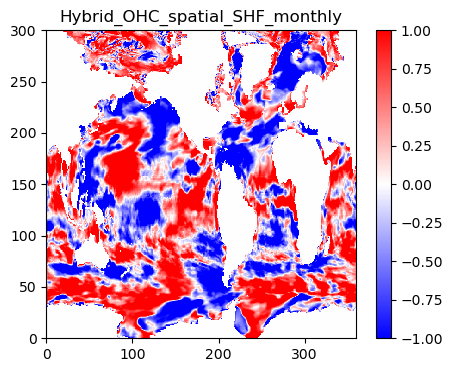

In [7]:
# -----------------------------------------------------------------------------
# Cell purpose: quick visual sanity check of sampled normalised fields by mode.
# -----------------------------------------------------------------------------
# Quick visual check of first variable at first time step for each strategy.
for i, strategy in enumerate(normalisation_strategies):
    plt.figure(figsize=(5, 4))
    plt.pcolor(all_np_by_mode[i][0, 1, :, :], vmin=-1, vmax=1, cmap=plt.cm.bwr)
    plt.colorbar()
    plt.title(strategy)


In [8]:
# -----------------------------------------------------------------------------
# Cell purpose: derive canonical ocean mask once from source data.
# This mask is reused for plotting, loss weighting, and diagnostics consistency.
# -----------------------------------------------------------------------------
# Keep mask derivation from source data so land points stay excluded from metrics/loss.
ds_mask = xr.open_dataset(userbase + "OM2-emulator/data/1deg_ocean_heat_emulator_data.nc")
mask_xr = xr.where(np.isnan(ds_mask.total_surface_heat_flx.isel(time=0)), 0, 1)
mask = mask_xr.values

## Do some checks - input data and partial convolutions

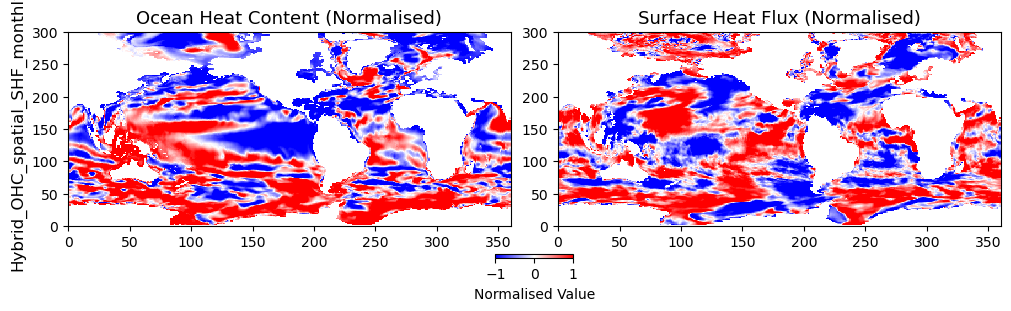

In [9]:
# -----------------------------------------------------------------------------
# Cell purpose: compare OHC/HF normalised snapshots across configured strategies.
# Channel convention is fixed by pipeline selection+sort order.
# -----------------------------------------------------------------------------
num_modes = len(pipelines_normed)
fig, axes = plt.subplots(nrows=num_modes, ncols=2, figsize=(10, 3 * num_modes), constrained_layout=True)

if num_modes == 1:
    axes = np.expand_dims(axes, axis=0)

for mode_idx, _norm_op in enumerate(pipelines_normed):
    OHC = np.where(mask, all_np_by_mode[mode_idx][0, 0, :, :], np.nan)
    QNET = np.where(mask, all_np_by_mode[mode_idx][0, 1, :, :], np.nan)

    pcm = axes[mode_idx, 0].pcolormesh(OHC, vmin=-1, vmax=1, cmap=plt.cm.bwr)
    axes[mode_idx, 1].pcolormesh(QNET, vmin=-1, vmax=1, cmap=plt.cm.bwr)

    axes[mode_idx, 0].set_ylabel(normalisation_strategies[mode_idx], fontsize=12)

axes[0, 0].set_title("Ocean Heat Content (Normalised)", fontsize=13)
axes[0, 1].set_title("Surface Heat Flux (Normalised)", fontsize=13)

cbar = fig.colorbar(pcm, ax=axes, orientation='horizontal', fraction=0.02, pad=0.02)
cbar.set_label("Normalised Value")
plt.savefig("/g/data/v46/txs156/OM2-emulator/figures/normlaisation_strategies.png", dpi=300, bbox_inches="tight")


Input shape: torch.Size([1, 1, 300, 360])
Input Mask shape: torch.Size([1, 1, 300, 360])
Output shape: torch.Size([1, 1, 150, 180])
New Mask shape: torch.Size([1, 1, 150, 180])
Original valid fraction: 0.6463796296296296
New valid fraction: 0.6898888945579529


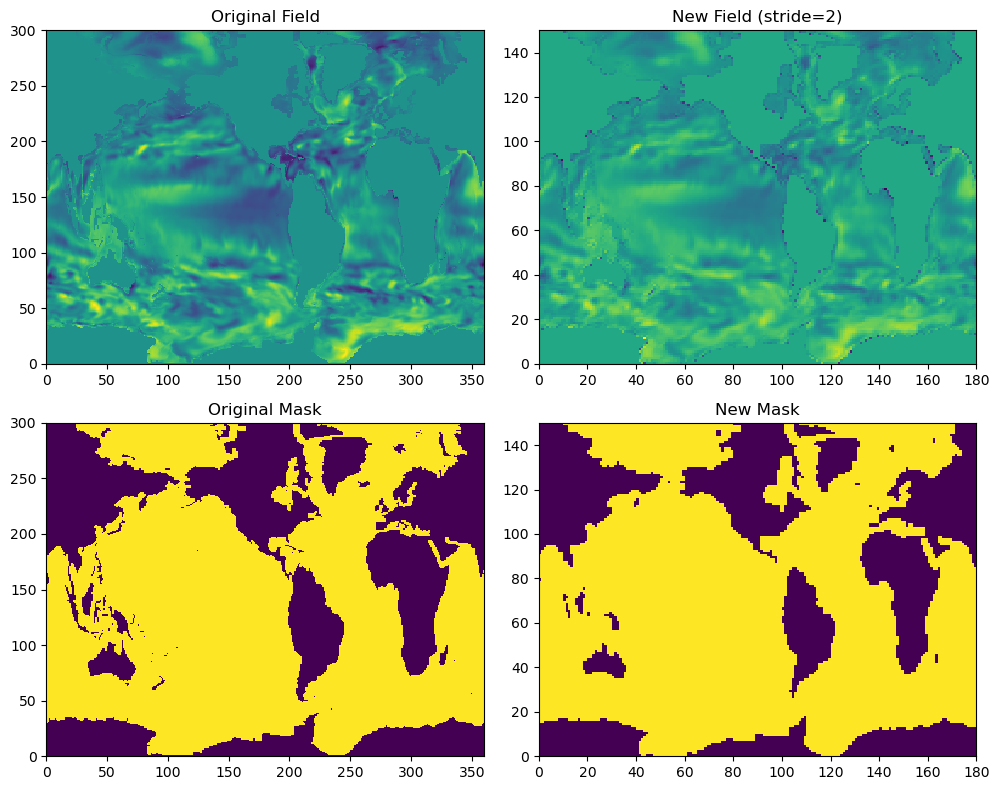

In [10]:
# -----------------------------------------------------------------------------
# Cell purpose: verify PartialConv mask propagation on one representative field.
# -----------------------------------------------------------------------------
# This guard makes the cell runnable after kernel restarts even if the import
# setup cell has not been executed in this session.
if "PartialConv2d" not in globals():
    try:
        from om2_model_utils import PartialConv2d
    except ModuleNotFoundError:
        import sys
        from pathlib import Path
        sys.path.insert(0, str((Path.cwd() / "../src").resolve()))
        from om2_model_utils import PartialConv2d

field = all_np_by_mode[0][0, 0, :, :]  # OHC (channel 0), first time step
x_field = torch.tensor(field, dtype=torch.float32)
mask_local = torch.tensor(mask, dtype=torch.float32)

x_field = x_field.unsqueeze(0).unsqueeze(0)
mask_local = mask_local.unsqueeze(0).unsqueeze(0)

layer = PartialConv2d(in_ch=1, out_ch=1, kernel_size=3, stride=2, padding=1)
out, new_mask = layer(x_field, mask_local)

print("Input shape:", x_field.shape)
print("Input Mask shape:", mask_local.shape)
print("Output shape:", out.shape)
print("New Mask shape:", new_mask.shape)

new_field = out.detach().squeeze().numpy()
new_mask_np = new_mask.detach().squeeze().numpy()

print("Original valid fraction:", mask.mean().item())
print("New valid fraction:", new_mask_np.mean().item())

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].pcolormesh(field)
axes[0, 0].set_title("Original Field")
axes[1, 0].pcolormesh(mask)
axes[1, 0].set_title("Original Mask")
axes[0, 1].pcolormesh(new_field)
axes[0, 1].set_title("New Field (stride=2)")
axes[1, 1].pcolormesh(new_mask_np)
axes[1, 1].set_title("New Mask")
plt.tight_layout()
plt.show()


## Define the model

In [11]:
# -----------------------------------------------------------------------------
# Cell purpose: define masked autoencoder with PartialConv encoder/decoder blocks.
# Land masking is enforced in forward() to prevent land imprint in outputs.
# -----------------------------------------------------------------------------
class AutoEncoder(nn.Module):

    def __init__(self,
                 input_channel_count=2,
                 output_channel_count=2):

        super(AutoEncoder, self).__init__()

        # ---------- Encoder ----------
        self.enc1 = PartialConv2d(input_channel_count, 16, kernel_size=4, stride=2, padding=1)
        self.enc2 = PartialConv2d(16, 32, kernel_size=3, stride=2, padding=1)
        self.enc3 = PartialConv2d(32, 64, kernel_size=7, stride=1, padding=3)

        # ---------- Decoder ----------
        self.dec1 = PartialConv2d(64, 32, kernel_size=7, stride=1, padding=3)
        self.dec2 = PartialConv2d(32, 16, kernel_size=3, stride=1, padding=1)
        self.dec3 = PartialConv2d(16, output_channel_count, kernel_size=4, stride=1, padding=2)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
    
    def encode(self, x, mask):
        """Encoder: returns latent representation and updated mask"""
        x, mask = self.enc1(x, mask)
        x = self.relu(x)
        x, mask = self.enc2(x, mask)
        x = self.relu(x)
        x, mask = self.enc3(x, mask)
        x = self.relu(x)
        return x, mask
    
    def decode(self, x, mask):
        """Decoder: takes latent representation and reconstructs output"""
        # upsample 1
        x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        mask = F.interpolate(mask, scale_factor=2, mode="nearest")

        x, mask = self.dec1(x, mask)
        x = self.relu(x)

        # upsample 2
        x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        mask = F.interpolate(mask, scale_factor=2, mode="nearest")

        x, mask = self.dec2(x, mask)
        x = self.relu(x)

        # final conv
        x, mask = self.dec3(x, mask)
        reconstructed = self.sigmoid(x)
        
        return reconstructed, mask
    
    def forward(self, x, mask):
        # Store input size for later
        input_h, input_w = x.shape[2], x.shape[3]

        # Encoder
        latent, latent_mask = self.encode(x, mask)

        # Decoder
        reconstructed, final_mask = self.decode(latent, latent_mask)
        
        # Crop to match input size (handles rounding errors from upsampling)
        reconstructed = reconstructed[:, :, :input_h, :input_w]

        return reconstructed



## Initialize model and prepare data for training

In [12]:
# -----------------------------------------------------------------------------
# Cell purpose: prepare tensors (all/train/eval) for model training and checks.
# -----------------------------------------------------------------------------
x_all = []
x_train = []
x_eval = []

for mode_idx in range(len(pipelines_normed)):
    x_all.append(torch.from_numpy(all_np_by_mode[mode_idx]).float())
    x_train.append(torch.from_numpy(train_np_by_mode[mode_idx]).float())
    x_eval.append(torch.from_numpy(eval_np_by_mode[mode_idx]).float())

model = AutoEncoder(
    input_channel_count=x_train[0].shape[1],
    output_channel_count=x_train[0].shape[1],
).to(device)

criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Shape [1, 1, H, W], broadcastable over [B, C, H, W]
mask_t = torch.tensor(mask, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)



Input shape: torch.Size([2, 2, 300, 360])
Mask shape: torch.Size([1, 1, 300, 360])
Prediction shape: torch.Size([2, 2, 300, 360])


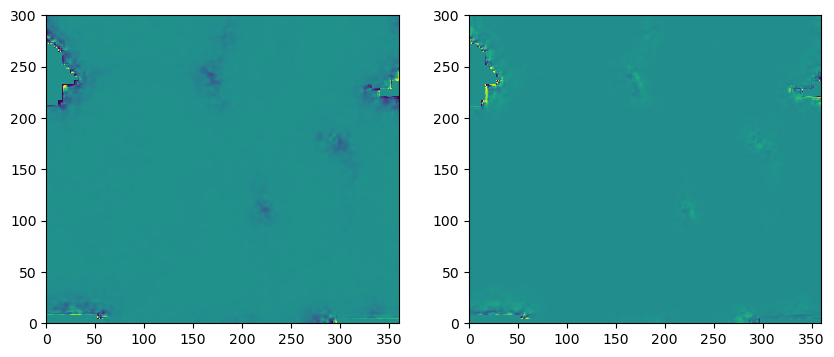

In [13]:
# -----------------------------------------------------------------------------
# Cell purpose: forward-pass smoke test before training.
# Use this to catch shape/channel/mask issues early.
# -----------------------------------------------------------------------------
if "mask_t" not in globals():
    mask_t = torch.tensor(mask, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

for i, _norm_op in enumerate(pipelines_normed):
    x_batch = x_train[i][:2].to(device)
    prediction = model(x_batch, mask_t)

    print("Input shape:", x_batch.shape)
    print("Mask shape:", mask_t.shape)
    print("Prediction shape:", prediction.shape)

    image_numpy_for_display = prediction.detach().cpu().numpy()
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].pcolormesh(image_numpy_for_display[0, 0])
    axes[1].pcolormesh(image_numpy_for_display[0, 1])
    plt.show()



In [14]:
# -----------------------------------------------------------------------------
# Cell purpose: print quick channel magnitude checks on training tensors.
# -----------------------------------------------------------------------------
print(np.max(x_train[0].numpy()[:, 1, :, :]))
print(np.max(x_train[0].numpy()[:, 0, :, :]))
print(np.max(x_eval[0].numpy()[:, 1, :, :]))


4.235373
8.1787405
4.2195997


## Training loop

In [15]:
%%time

# -----------------------------------------------------------------------------
# Cell purpose: train autoencoder on training timesteps and monitor eval loss
# on the latest 20% split.
# -----------------------------------------------------------------------------
def masked_recon_loss(y, x_in, mask_t):
    diff = torch.abs(y - x_in)
    return (diff * mask_t).sum() / (mask_t.sum() * x_in.shape[0])


def run_epoch(model, loader, mask_t, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    running = 0.0
    n_batches = 0

    for (xb,) in loader:
        xb = xb.to(device)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            yb = model(xb, mask_t)
            loss = masked_recon_loss(yb, xb, mask_t)

            if is_train:
                loss.backward()
                optimizer.step()

        running += loss.item()
        n_batches += 1

    return running / max(n_batches, 1)


models_by_mode = []
history_by_mode = {}

num_epochs = 200
batch_size = 8

for mode_idx, mode_name in enumerate(normalisation_strategies):
    model_i = AutoEncoder(
        input_channel_count=x_train[mode_idx].shape[1],
        output_channel_count=x_train[mode_idx].shape[1],
    ).to(device)
    optimizer_i = optim.Adam(model_i.parameters(), lr=1e-4)

    train_loader = DataLoader(TensorDataset(x_train[mode_idx]), batch_size=batch_size, shuffle=True)
    eval_loader = DataLoader(TensorDataset(x_eval[mode_idx]), batch_size=batch_size, shuffle=False)

    train_hist = []
    eval_hist = []

    for epoch in range(num_epochs):
        tr_loss = run_epoch(model_i, train_loader, mask_t, optimizer=optimizer_i)
        ev_loss = run_epoch(model_i, eval_loader, mask_t, optimizer=None)

        train_hist.append(tr_loss)
        eval_hist.append(ev_loss)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"{mode_name} | Epoch {epoch+1:03d}/{num_epochs} | train={tr_loss:.6f} | eval={ev_loss:.6f}")

    models_by_mode.append(model_i)
    history_by_mode[mode_name] = {"train": train_hist, "eval": eval_hist}

# Backward compatibility with downstream cells expecting `model`.
model = models_by_mode[0]


Hybrid_OHC_spatial_SHF_monthly | Epoch 001/200 | train=1.747059 | eval=1.751083
Hybrid_OHC_spatial_SHF_monthly | Epoch 010/200 | train=1.183459 | eval=1.233459
Hybrid_OHC_spatial_SHF_monthly | Epoch 020/200 | train=1.135950 | eval=1.189923
Hybrid_OHC_spatial_SHF_monthly | Epoch 030/200 | train=1.120420 | eval=1.173050
Hybrid_OHC_spatial_SHF_monthly | Epoch 040/200 | train=1.109841 | eval=1.161633
Hybrid_OHC_spatial_SHF_monthly | Epoch 050/200 | train=1.101622 | eval=1.156158
Hybrid_OHC_spatial_SHF_monthly | Epoch 060/200 | train=1.098107 | eval=1.150223
Hybrid_OHC_spatial_SHF_monthly | Epoch 070/200 | train=1.094787 | eval=1.147555
Hybrid_OHC_spatial_SHF_monthly | Epoch 080/200 | train=1.090890 | eval=1.143574
Hybrid_OHC_spatial_SHF_monthly | Epoch 090/200 | train=1.087680 | eval=1.139064
Hybrid_OHC_spatial_SHF_monthly | Epoch 100/200 | train=1.086858 | eval=1.137886
Hybrid_OHC_spatial_SHF_monthly | Epoch 110/200 | train=1.081986 | eval=1.135214
Hybrid_OHC_spatial_SHF_monthly | Epoch 1

## Compute final prediction

In [16]:
# -----------------------------------------------------------------------------
# Cell purpose: predict one selected month slice from full PET-processed series.
# -----------------------------------------------------------------------------
target_month = pd.DatetimeIndex(time_by_mode[0])[-1].strftime("%Y-%m")  # true last available month

x_month_by_mode = []
prediction_np_by_mode = []
input_np_by_mode = []
prediction_time_by_mode = []

for mode_idx, mode_name in enumerate(normalisation_strategies):
    mode_times = pd.DatetimeIndex(time_by_mode[mode_idx])
    month_mask = mode_times.to_period("M") == pd.Period(target_month, freq="M")
    month_indices = np.where(month_mask)[0]

    if len(month_indices) == 0:
        raise ValueError(f"{target_month} not found for mode {mode_name}")

    month_idx = int(month_indices[0])
    x_month = x_all[mode_idx][month_idx:month_idx+1].to(device)

    model_i = models_by_mode[mode_idx]
    model_i.eval()
    with torch.no_grad():
        pred = model_i(x_month, mask_t)

    x_month_by_mode.append(x_month)
    prediction_np_by_mode.append(pred.detach().cpu().numpy())
    input_np_by_mode.append(x_month.detach().cpu().numpy())
    prediction_time_by_mode.append(mode_times[month_idx].to_datetime64())

    print(f"{mode_name} | month={mode_times[month_idx].strftime('%Y-%m')} | slice shape={x_month.shape}")


Hybrid_OHC_spatial_SHF_monthly | month=2018-11 | slice shape=torch.Size([1, 2, 300, 360])


In [17]:
# -----------------------------------------------------------------------------
# Cell purpose: build consolidated diagnostics artefacts for month-slice
# predictions in physical units.
# -----------------------------------------------------------------------------
import numpy as np
import xarray as xr
import torch

NORMALISATION_MODES = list(normalisation_strategies)
selected_mode_for_detail = NORMALISATION_MODES[0]

mean_stats_by_mode = [global_mean_stats, spatial_mean_stats, spatial_monthly_mean_stats, hybrid_mean_stats]

CHANNEL_TO_VAR = {ch: var for ch, var in enumerate(normalised_variables)}
VAR_TO_CHANNEL = {v: k for k, v in CHANNEL_TO_VAR.items()}
DISPLAY_CHANNEL_VARS = list(normalised_variables)


def _resolve_spatial_layout(sample_h, sample_w):
    ref_var = normalised_variables[0]

    if ref_var in spatial_mean_stats.data_vars:
        dims = [d for d in spatial_mean_stats[ref_var].dims if d != "time"]
        if len(dims) >= 2:
            y_dim, x_dim = dims[-2], dims[-1]
            y_vals = spatial_mean_stats.coords[y_dim].values if y_dim in spatial_mean_stats.coords else np.arange(sample_h)
            x_vals = spatial_mean_stats.coords[x_dim].values if x_dim in spatial_mean_stats.coords else np.arange(sample_w)
            return y_dim, x_dim, y_vals, x_vals

    return "latitude", "longitude", np.arange(sample_h), np.arange(sample_w)


def _tensor_to_dataset(sample_np, sample_time):
    sample_h, sample_w = sample_np.shape[2], sample_np.shape[3]
    y_dim, x_dim, y_vals, x_vals = _resolve_spatial_layout(sample_h, sample_w)

    ds = xr.Dataset(
        {
            CHANNEL_TO_VAR[ch]: (("time", y_dim, x_dim), sample_np[:, ch, :, :])
            for ch in sorted(CHANNEL_TO_VAR)
        },
        coords={
            "time": [sample_time],
            y_dim: y_vals,
            x_dim: x_vals,
        },
    )
    return ds


def _stack_display_vars(ds_mode):
    arrs = []
    for v in DISPLAY_CHANNEL_VARS:
        da = ds_mode[v]
        if "time" in da.dims:
            da = da.isel(time=0, drop=True)
        arrs.append(np.asarray(da.values))
    return np.stack(arrs, axis=0)[np.newaxis, ...]


results_by_mode = {}
prediction_display_by_mode = {}
input_display_by_mode = {}

for mode_idx, mode in enumerate(NORMALISATION_MODES):
    x_mode = x_month_by_mode[mode_idx]
    model_i = models_by_mode[mode_idx]

    model_i.eval()
    with torch.no_grad():
        latent, _ = model_i.encode(x_mode, mask_t)

    pred_np = prediction_np_by_mode[mode_idx]
    input_np = input_np_by_mode[mode_idx]
    sample_time = prediction_time_by_mode[mode_idx]

    pred_ds_mode = _tensor_to_dataset(pred_np, sample_time)
    input_ds_mode = _tensor_to_dataset(input_np, sample_time)

    pred_phys_ds_mode = pipelines_normed[mode_idx].undo(pred_ds_mode)
    input_phys_ds_mode = pipelines_normed[mode_idx].undo(input_ds_mode)

    pred_display = _stack_display_vars(pred_phys_ds_mode)
    input_display = _stack_display_vars(input_phys_ds_mode)

    prediction_display_by_mode[mode] = pred_display
    input_display_by_mode[mode] = input_display

    results_by_mode[mode] = {
        "latent": latent.detach().cpu().numpy()[0],
        "prediction": pred_display,
        "input": input_display,
    }

In [18]:
# -----------------------------------------------------------------------------
# Cell purpose: validate that per-mode 'actual' fields align over ocean points.
# -----------------------------------------------------------------------------
# Compare per-mode "actual" only over ocean (sanity check).
# If masking/undo are consistent, these differences should be near zero over ocean.

ocean_mask = mask.astype(bool)
reference_mode = NORMALISATION_MODES[0]
reference_actual = input_display_by_mode[reference_mode]

print(f"Reference mode: {reference_mode}")

for mode in NORMALISATION_MODES:
    actual = input_display_by_mode[mode]
    print(f"\nMode: {mode}")

    for var_name in DISPLAY_CHANNEL_VARS:
        ch = VAR_TO_CHANNEL[var_name]
        diff = np.where(ocean_mask, actual[0, ch] - reference_actual[0, ch], np.nan)

        max_abs = float(np.nanmax(np.abs(diff)))
        mean_abs = float(np.nanmean(np.abs(diff)))
        rmse = float(np.sqrt(np.nanmean(diff**2)))

        print(
            f"  {var_name}: max|Δ|={max_abs:.6e}, mean|Δ|={mean_abs:.6e}, RMSE={rmse:.6e}"
        )



Reference mode: Hybrid_OHC_spatial_SHF_monthly

Mode: Hybrid_OHC_spatial_SHF_monthly
  ocean_heat_content_2d: max|Δ|=0.000000e+00, mean|Δ|=0.000000e+00, RMSE=0.000000e+00
  total_surface_heat_flx: max|Δ|=0.000000e+00, mean|Δ|=0.000000e+00, RMSE=0.000000e+00


## 
Diagnostics

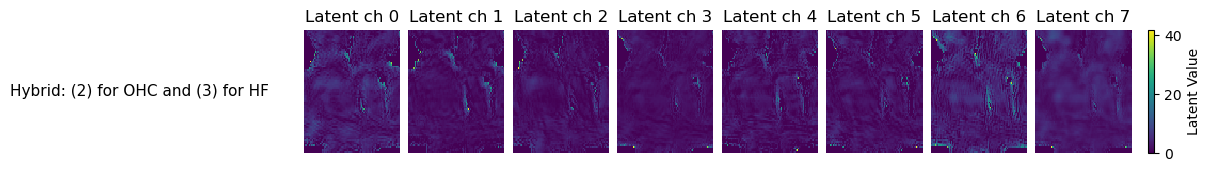

In [19]:
# -----------------------------------------------------------------------------
# Cell purpose: plot latent channels across normalisation modes for comparison.
# -----------------------------------------------------------------------------
# ---- Clean labels ----
normalisation_clean = [
    "Hybrid: (2) for OHC and (3) for HF"
]
# ---- Filter out the 3rd strategy (index 2) ----
modes_to_plot = [m for i, m in enumerate(NORMALISATION_MODES) if i != 2]
labels_to_plot = [l for i, l in enumerate(normalisation_clean) if i != 2]

n_rows = len(modes_to_plot)
n_latent_show = min(8, min(results_by_mode[mode]["latent"].shape[0] for mode in modes_to_plot))

fig, axs = plt.subplots(
    n_rows, n_latent_show,
    figsize=(3 * n_latent_show*0.5, 3.2 * n_rows*0.5),
    constrained_layout=True
)

# Handle single-row edge case
if n_rows == 1:
    axs = np.expand_dims(axs, axis=0)

for row, (mode, label) in enumerate(zip(modes_to_plot, labels_to_plot)):
    z = results_by_mode[mode]["latent"]  # (C_latent, H, W)

    for col in range(n_latent_show):
        ax = axs[row, col]
        im = ax.pcolormesh(z[col], cmap="viridis")

        # ---- Clean look WITHOUT killing labels ----
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

        # Column titles (top row only)
        if row == 0:
            ax.set_title(f"Latent ch {col}")

    # ---- Row labels (first column only) ----
    axs[row, 0].set_ylabel(
        label,
        fontsize=11,
        rotation=0,
        ha='right',
        va='center',
        labelpad=25
    )

# ---- Single shared colorbar ----
cbar = fig.colorbar(im, ax=axs, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label("Latent Value")
plt.savefig("/g/data/v46/txs156/OM2-emulator/figures/latent_space.png", dpi=300, bbox_inches="tight")

plt.show()

In [20]:
# -----------------------------------------------------------------------------
# Cell purpose: compute area-weighted RMSE for OHC and cumulative HF by mode.
# -----------------------------------------------------------------------------
## Compute RMSE (all normalisation modes)

# Shared area weights for fair spatially weighted RMSE across all modes.
ds = xr.open_dataset(userbase + "OM2-emulator/data/1deg_ocean_heat_emulator_data.nc")
area_t = ds.area_t.values.astype(np.float64)
area_weighted = area_t * mask

RMSE_by_mode = {}
for mode in NORMALISATION_MODES:
    pred = prediction_display_by_mode[mode]
    obs = input_display_by_mode[mode]

    # Channel convention in this notebook:
    # [0] = total_surface_heat_flx (QNET), [1] = ocean_heat_content_2d (OHC)
    err_ohc = pred[0, VAR_TO_CHANNEL["ocean_heat_content_2d"]] - obs[0, VAR_TO_CHANNEL["ocean_heat_content_2d"]]
    err_sfx = pred[0, VAR_TO_CHANNEL["total_surface_heat_flx"]] - obs[0, VAR_TO_CHANNEL["total_surface_heat_flx"]]

    rmse_ohc = np.sqrt(np.nansum(err_ohc**2 * area_weighted) / np.nansum(area_weighted))
    rmse_sfx = np.sqrt(np.nansum(err_sfx**2 * area_weighted) / np.nansum(area_weighted))

    RMSE_by_mode[mode] = {
        "heat_flux": float(rmse_sfx),
        "ohc": float(rmse_ohc),
    }

    print(f"{mode} | RMSE heat_flux: {rmse_sfx:.6e}, RMSE OHC: {rmse_ohc:.6e}")

# Backward-compatible RMSE list for selected mode only.
RMSE = [
    RMSE_by_mode[selected_mode_for_detail]["heat_flux"],
    RMSE_by_mode[selected_mode_for_detail]["ohc"],
]


Hybrid_OHC_spatial_SHF_monthly | RMSE heat_flux: 1.928758e+01, RMSE OHC: 9.390206e+08


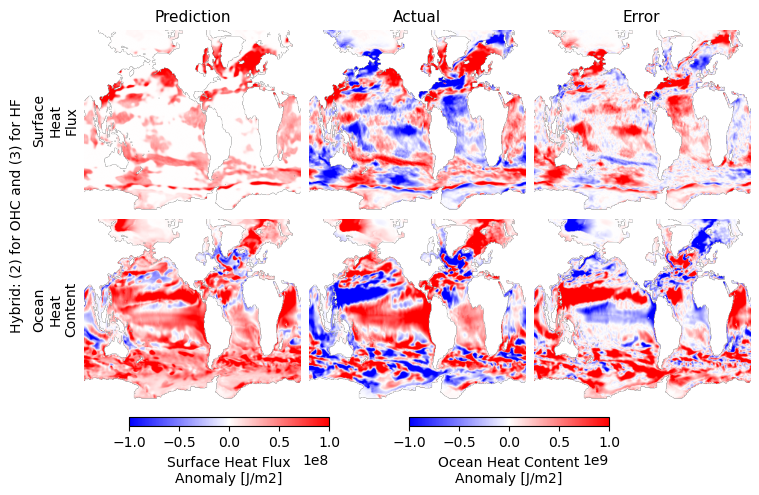

In [51]:
# -----------------------------------------------------------------------------
# Cell purpose: map-level prediction/actual/error diagnostics in physical units.
# -----------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

normalisation_clean = [
    "Hybrid: (2) for OHC and (3) for HF"
]

num_modes = len(NORMALISATION_MODES)

fig, axes = plt.subplots(
    nrows=2 * num_modes,
    ncols=3,
    figsize=(4*2, 2.2 * num_modes*2),
    gridspec_kw=dict(wspace=0.01, hspace=0.05)
)

if 2 * num_modes == 1:
    axes = np.expand_dims(axes, axis=0)

reference_mode = NORMALISATION_MODES[0]
obs_ref = input_display_by_mode[reference_mode]
ocean_mask = mask.astype(bool)

# Tight margins (this is key)
fig.subplots_adjust(left=0.14, right=0.98, top=0.96, bottom=0.12)

for mode_idx, mode in enumerate(NORMALISATION_MODES):
    pred = prediction_display_by_mode[mode]
    clean_label = normalisation_clean[mode_idx]

    # =========================
    # Heat Flux
    # =========================
    row_h = 2 * mode_idx

    pred_h = np.where(ocean_mask, pred[0, VAR_TO_CHANNEL["total_surface_heat_flx"]] * (30 * 24 * 3600), np.nan)
    obs_h  = np.where(ocean_mask, obs_ref[0, VAR_TO_CHANNEL["total_surface_heat_flx"]] * (30 * 24 * 3600), np.nan)
    err_h  = pred_h - obs_h

    im_h = axes[row_h, 0].imshow(pred_h - spatial_monthly_mean_stats.sel(time=mode_times[month_idx].strftime('%Y-%m')).total_surface_heat_flx[0,:,:] * (30 * 24 * 3600), vmin=-1e8, vmax=1e8, cmap=plt.cm.bwr)
    axes[row_h, 1].imshow(obs_h - spatial_monthly_mean_stats.sel(time=mode_times[month_idx].strftime('%Y-%m')).total_surface_heat_flx[0,:,:] * (30 * 24 * 3600),  vmin=-1e8, vmax=1e8, cmap=plt.cm.bwr)
    axes[row_h, 2].imshow(err_h,  vmin=-1e8, vmax=1e8, cmap=plt.cm.bwr)

    # =========================
    # OHC
    # =========================
    row_o = 2 * mode_idx + 1

    pred_o = np.where(ocean_mask, pred[0, VAR_TO_CHANNEL["ocean_heat_content_2d"]], np.nan)
    obs_o  = np.where(ocean_mask, obs_ref[0, VAR_TO_CHANNEL["ocean_heat_content_2d"]], np.nan)
    err_o  = pred_o - obs_o

    im_o = axes[row_o, 0].imshow(pred_o - spatial_monthly_mean_stats.sel(time=mode_times[month_idx].strftime('%Y-%m')).ocean_heat_content_2d[0,:,:], vmin=-1e9, vmax=1e9, cmap=plt.cm.bwr)
    axes[row_o, 1].imshow(obs_o - spatial_monthly_mean_stats.sel(time=mode_times[month_idx].strftime('%Y-%m')).ocean_heat_content_2d[0,:,:],  vmin=-1e9, vmax=1e9, cmap=plt.cm.bwr)
    axes[row_o, 2].imshow(err_o,  vmin=-1e9, vmax=1e9, cmap=plt.cm.bwr)

    # =========================
    # Clean styling
    # =========================
    for r in [row_h, row_o]:
        for c in range(3):
            ax = axes[r, c]
            ax.invert_yaxis()
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)

    # Column titles once
    if mode_idx == 0:
        axes[row_h, 0].set_title("Prediction", fontsize=11)
        axes[row_h, 1].set_title("Actual", fontsize=11)
        axes[row_h, 2].set_title("Error", fontsize=11)

    # Variable labels
    axes[row_h, 0].set_ylabel("Surface\nHeat\nFlux", fontsize=10)
    axes[row_o, 0].set_ylabel("Ocean\nHeat\nContent", fontsize=10)

    # Centered normalisation label (row pair)
    pos_h = axes[row_h, 0].get_position()
    pos_o = axes[row_o, 0].get_position()
    y_mid = 0.5 * (pos_h.y1 + pos_o.y0)

    fig.text(
        0.06,
        y_mid,
        clean_label,
        ha="center",
        va="center",
        rotation=90,
        fontsize=10
    )

# =========================
# Shared horizontal colorbars
# =========================

# HF colorbar
cax_h = fig.add_axes([0.2, 0.06, 0.25, 0.02])
cbar_h = fig.colorbar(im_h, cax=cax_h, orientation="horizontal")
cbar_h.set_label("Surface Heat Flux\nAnomaly [J/m2]")

# OHC colorbar
cax_o = fig.add_axes([0.55, 0.06, 0.25, 0.02])
cbar_o = fig.colorbar(im_o, cax=cax_o, orientation="horizontal")
cbar_o.set_label("Ocean Heat Content\nAnomaly [J/m2]")
plt.savefig("/g/data/v46/txs156/OM2-emulator/figures/Error_assessment.png", dpi=300, bbox_inches="tight")

plt.show()

In [46]:
# -----------------------------------------------------------------------------
# Cell purpose: compute integrated diagnostics series used for global comparisons.
# -----------------------------------------------------------------------------
# Compute integrated diagnostics for each normalisation mode with a shared
# canonical input field (mode-independent truth).

ocean_mask = mask.astype(bool)
area_weighted = np.where(ocean_mask, area_t, np.nan)

reference_mode = NORMALISATION_MODES[0]
obs_ref = input_display_by_mode[reference_mode]

integrated_series_by_mode = {}
for mode in NORMALISATION_MODES:
    pred = prediction_display_by_mode[mode]

    integrated_series_by_mode[mode] = {
        "OHC_pred_J": np.nansum((pred[0, VAR_TO_CHANNEL["ocean_heat_content_2d"]] - spatial_monthly_mean_stats.sel(time=mode_times[month_idx].strftime('%Y-%m')).ocean_heat_content_2d[0,:,:]) * area_weighted, axis=1),
        "SFX_pred_J": np.nansum((pred[0, VAR_TO_CHANNEL["total_surface_heat_flx"]] - spatial_monthly_mean_stats.sel(time=mode_times[month_idx].strftime('%Y-%m')).total_surface_heat_flx[0,:,:]) * area_weighted * 30 * 24 * 3600, axis=1),
        "OHC_in_J": np.nansum((obs_ref[0, VAR_TO_CHANNEL["ocean_heat_content_2d"]] - spatial_monthly_mean_stats.sel(time=mode_times[month_idx].strftime('%Y-%m')).ocean_heat_content_2d[0,:,:]) * area_weighted, axis=1),
        "SFX_in_J": np.nansum((obs_ref[0, VAR_TO_CHANNEL["total_surface_heat_flx"]] - spatial_monthly_mean_stats.sel(time=mode_times[month_idx].strftime('%Y-%m')).total_surface_heat_flx[0,:,:]) * area_weighted * 30 * 24 * 3600, axis=1),
    }

# Backward-compatible aliases.
OHC_pred_J = integrated_series_by_mode[selected_mode_for_detail]["OHC_pred_J"]
SFX_pred_J = integrated_series_by_mode[selected_mode_for_detail]["SFX_pred_J"]
OHC_in_J = integrated_series_by_mode[reference_mode]["OHC_in_J"]
SFX_in_J = integrated_series_by_mode[reference_mode]["SFX_in_J"]



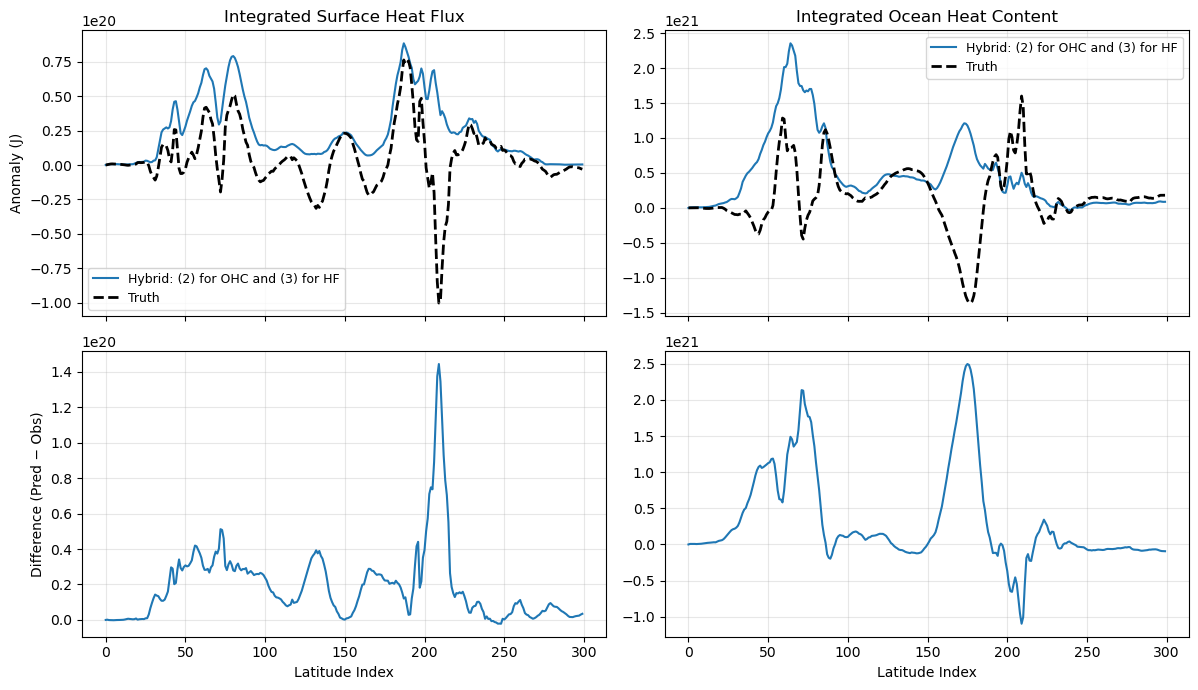

In [52]:
# -----------------------------------------------------------------------------
# Cell purpose: plot integrated totals and residuals across normalisation modes.
# -----------------------------------------------------------------------------
import matplotlib.pyplot as plt

normalisation_clean = [
    "Hybrid: (2) for OHC and (3) for HF"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)

# Reference (observations)
reference_mode = NORMALISATION_MODES[0]
SFX_obs = integrated_series_by_mode[reference_mode]["SFX_in_J"]
OHC_obs = integrated_series_by_mode[reference_mode]["OHC_in_J"]

for i, mode in enumerate(NORMALISATION_MODES):
    label = normalisation_clean[i]

    SFX_pred = integrated_series_by_mode[mode]["SFX_pred_J"]
    OHC_pred = integrated_series_by_mode[mode]["OHC_pred_J"]

    # ---- Top row: timeseries ----
    axes[0, 0].plot(SFX_pred, label=label)
    axes[0, 1].plot(OHC_pred, label=label)

    # ---- Bottom row: differences ----
    axes[1, 0].plot(SFX_pred - SFX_obs, label=label)
    axes[1, 1].plot(OHC_pred - OHC_obs, label=label)

# ---- Observations (top row only) ----
axes[0, 0].plot(SFX_obs, "k--", linewidth=2, label="Truth")
axes[0, 1].plot(OHC_obs, "k--", linewidth=2, label="Truth")

# ---- Titles ----
axes[0, 0].set_title("Integrated Surface Heat Flux")
axes[0, 1].set_title("Integrated Ocean Heat Content")

# ---- Row labels ----
axes[0, 0].set_ylabel("Anomaly (J)")
axes[1, 0].set_ylabel("Difference (Pred − Obs)")
axes[1, 0].set_xlabel("Latitude Index")
axes[1, 1].set_xlabel("Latitude Index")

# ---- Styling ----
for ax in axes.flat:
    ax.grid(True, alpha=0.3)

# Legends (only once per column to avoid clutter)
axes[0, 0].legend(fontsize=9)
axes[0, 1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("/g/data/v46/txs156/OM2-emulator/figures/Flux_integral.png", dpi=300, bbox_inches="tight")

plt.show()

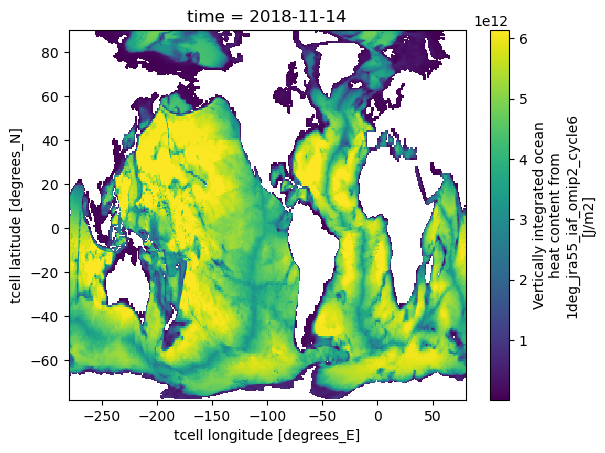

In [32]:
# -----------------------------------------------------------------------------
# Cell purpose: final scratch cell reserved for ad-hoc checks/experiments.
# -----------------------------------------------------------------------------
.plot()

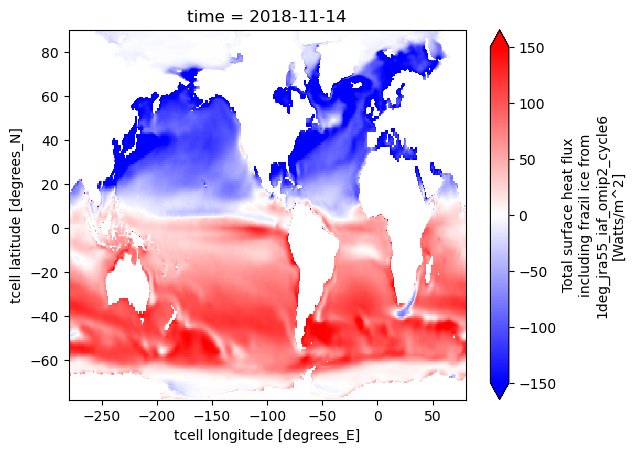